<a href="https://colab.research.google.com/github/Sazid669/Optimization_robotics/blob/IFRoS-Master/cem_lates_lecture_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let us find of the following function using Cross Entropy Method (CEM)

\begin{align}
f(x_1, x_2) = (x_1+x_2-3)^2+(2x_1-6x_2-4)^2
\end{align}

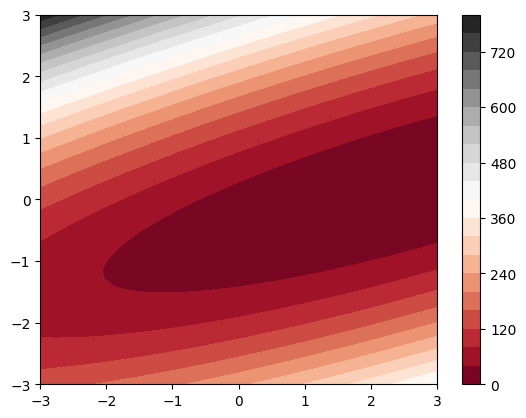

In [ ]:
## Let us visualize this function

import numpy as np
import matplotlib.pyplot as plt

x_1 = np.linspace(-3, 3)
x_2 = np.linspace(-3, 3)

X_1, X_2 = np.meshgrid(x_1, x_2)

f = (X_1+X_2-3)**2+(2*X_1-6*X_2-4)**2

plt.contourf(X_1, X_2, f, 20, cmap='RdGy')
plt.colorbar()
plt.show()


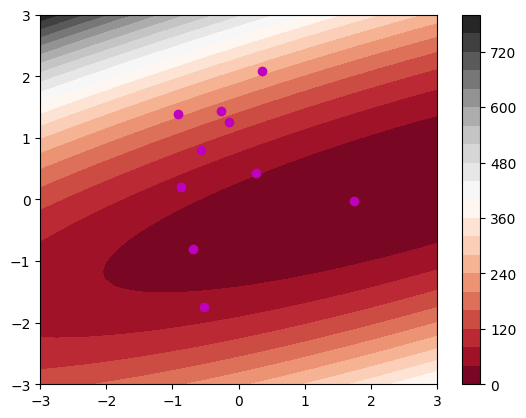

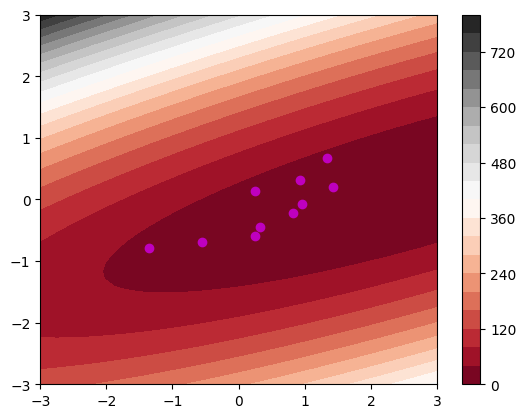

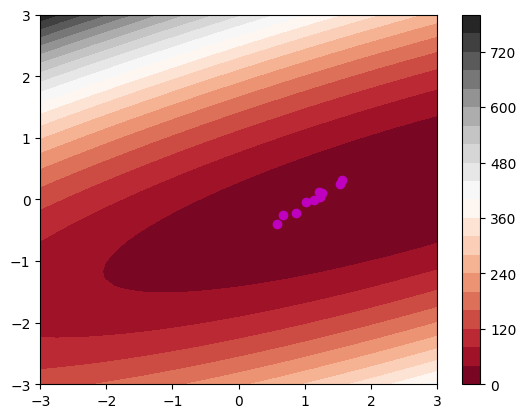

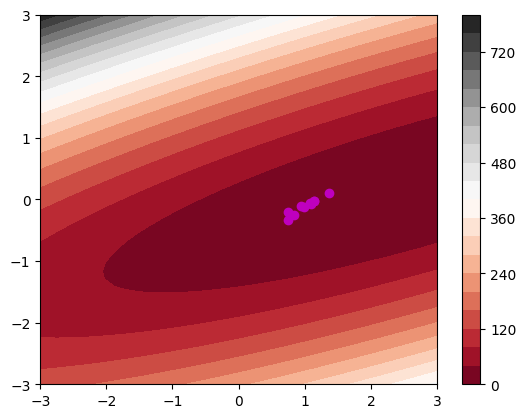

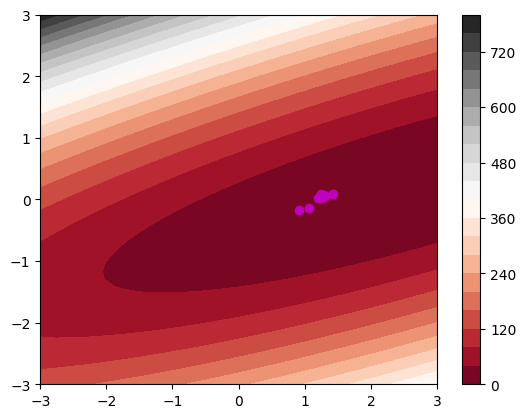

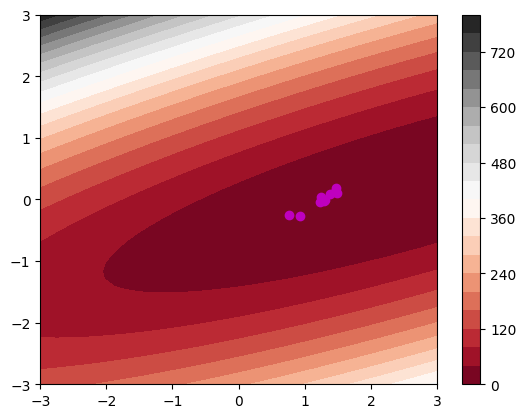

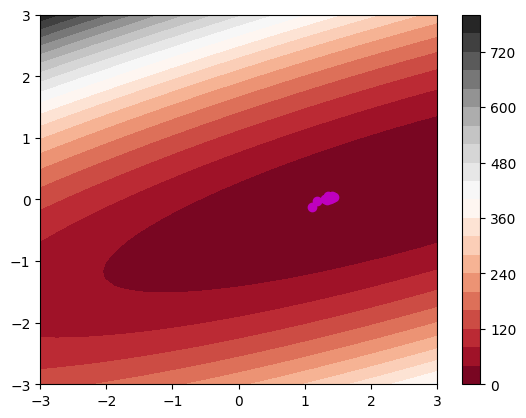

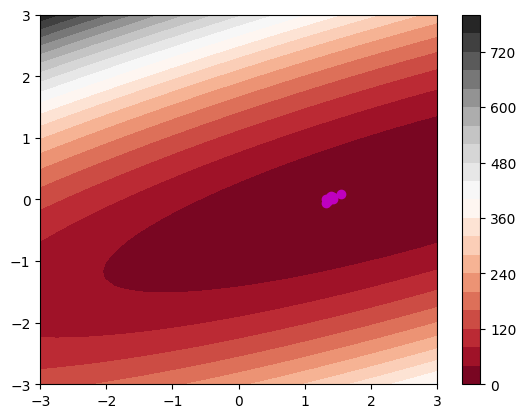

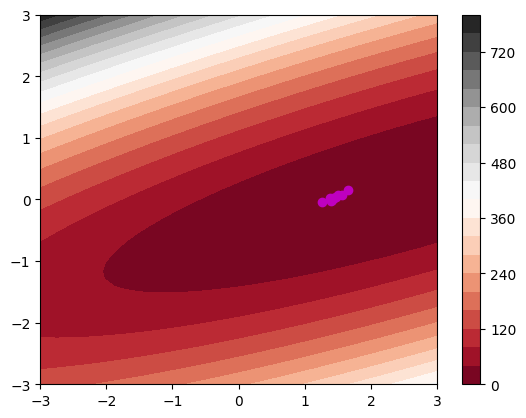

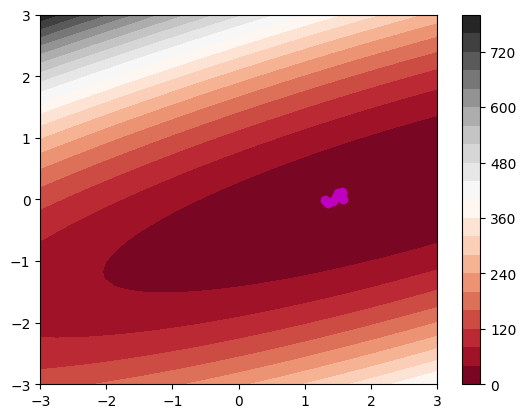

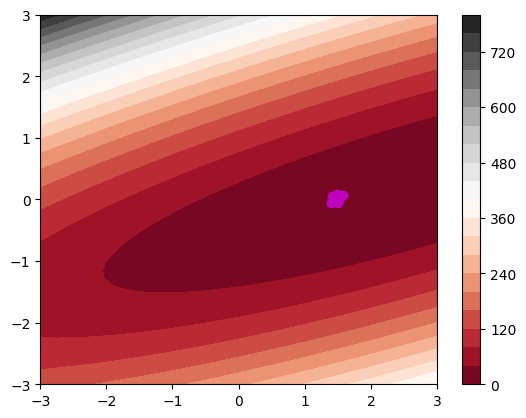

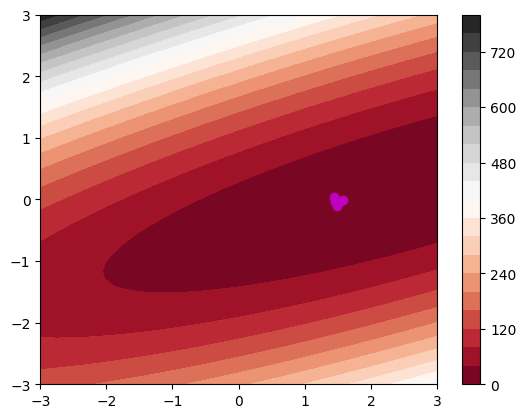

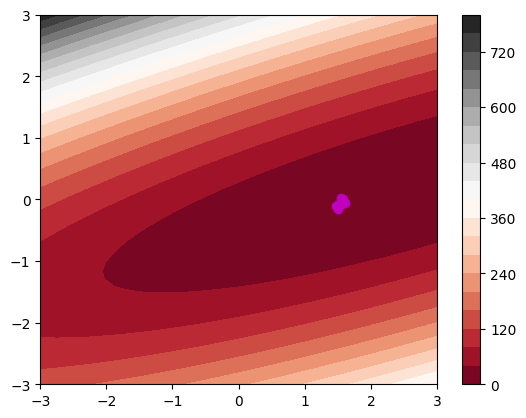

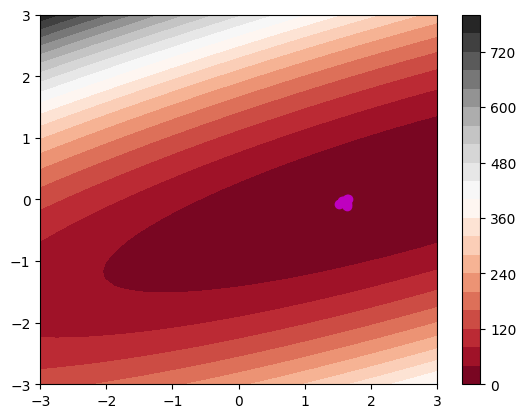

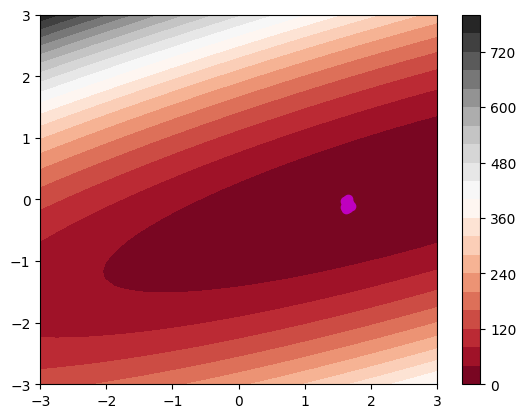

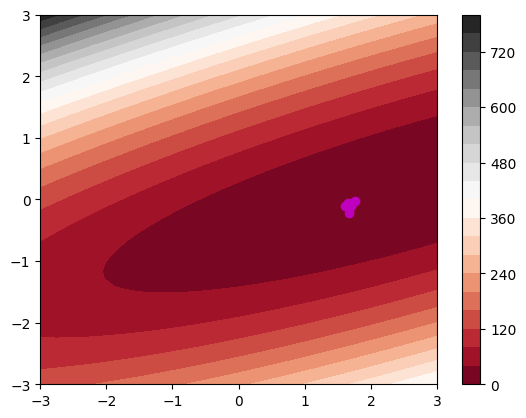

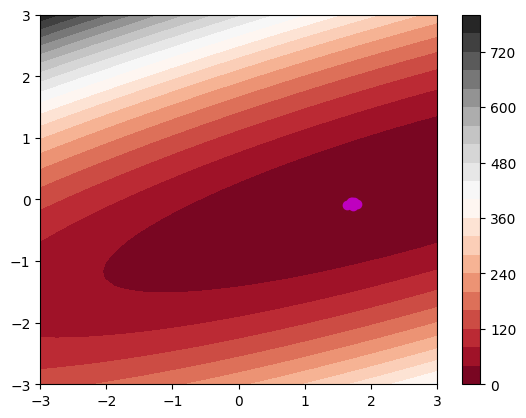

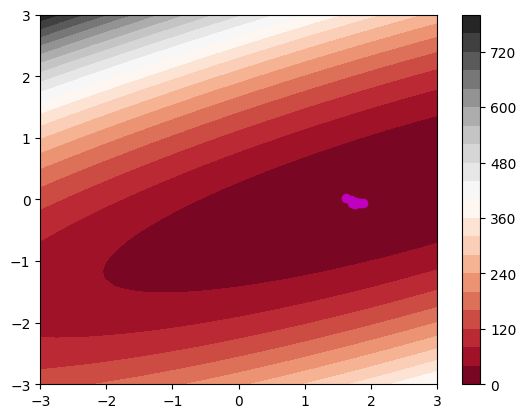

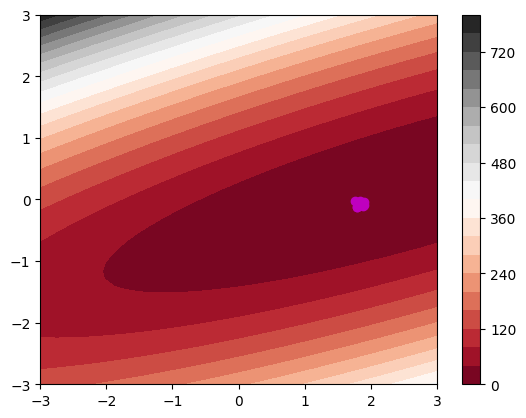

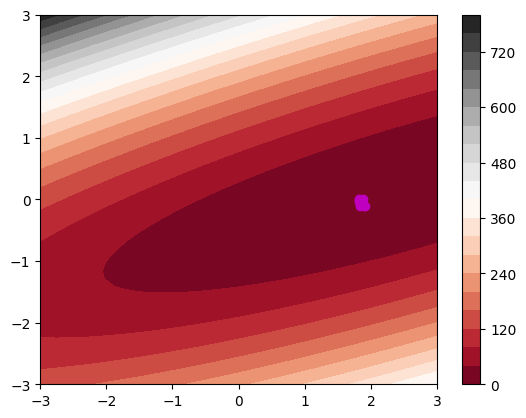

best_cost =  1.3127617
x_best =  [1.8814933  0.00651787]


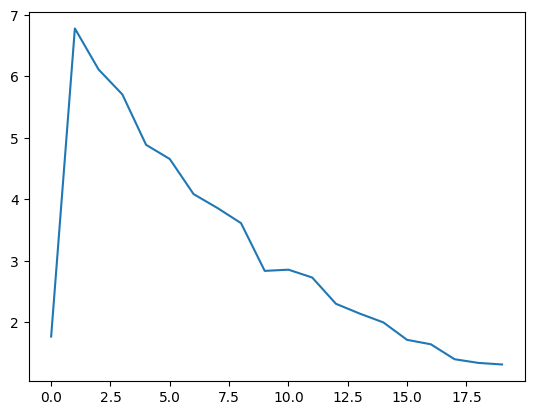

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, random, vmap
import jax

def compute_cost(x): ### f(x)

  x_1 = x[0]
  x_2 = x[1]

  cost = (x_1+x_2-3)**2+(2*x_1-6*x_2-4)**2
  return cost


##### Lets try the random sampling first

init_mean = jnp.hstack(( 0.0, 0.0  ))
init_cov = jnp.identity(2)
key = random.PRNGKey(0)
key, subkey = random.split(key)
num_samples = 10

# ### drawing random samples of x
# x = jax.random.multivariate_normal(key, init_mean, init_cov, (num_samples, ))

# # print(x)

# #### computing cost over all x

# cost_samples = []

# for i in range(0, num_samples):

#   cost_samples.append(compute_cost(x[i]))


# cost_samples = jnp.asarray(cost_samples)

# min_cost = jnp.min(cost_samples)
# min_index = jnp.argmin(cost_samples)

# print('best_cost = ', min_cost   )
# print('x_best = ', x[min_index]   )


############ Now lets take it up a notch and do full blown CEM




compute_cost_batch = jit(vmap(compute_cost, in_axes = (0)  )) ### parallel cost function call

maxiter = 20

cost_track = []

x_1 = np.linspace(-3, 3)
x_2 = np.linspace(-3, 3)

X_1, X_2 = np.meshgrid(x_1, x_2)
f = (X_1+X_2-3)**2+(2*X_1-6*X_2-4)**2

for i in range(0,maxiter):
  key, subkey = random.split(key)
  x = jax.random.multivariate_normal(key, init_mean, init_cov, (num_samples, )) ### step 1 Sampling(first building block)

  ## x is  matrix of dimension num_samples times (number of variables = 2)
  cost_samples = compute_cost_batch(x) ### step 2, evaluating f(x)
  idx = jnp.argsort(cost_samples) ### 3


  plt.plot(x[:, 0], x[:, 1], 'om', )
  plt.contourf(X_1, X_2, f, 20, cmap='RdGy')
  plt.colorbar()
  plt.xlim(-3, 3)
  plt.ylim(-3, 3)

  plt.show()

  ellite_num = int(num_samples*0.3) ### taking top m %

  x_ellite = x[idx[0:ellite_num]] ### 3


  init_mean = jnp.mean(x_ellite, axis = 0)

  init_cov = jnp.cov(x_ellite.T)+0.001*jnp.identity(2)

  cost_track.append(jnp.min(cost_samples))

idx_min = jnp.argmin(cost_samples)

print('best_cost = ', cost_samples[idx_min]   )
print('x_best = ', x[idx_min]   )

plt.plot(cost_track)

plt.show()


Let us now apply CEM to the IK problem

\begin{align}
\min_{\theta_1, \theta_2, \theta_3} (l_1\cos \theta_1+l_2\cos(\theta_1+\theta_2)+l_3 \cos(\theta_1+\theta_2+\theta_3)-x_f)^2+(l_1\sin \theta_1+l_2\sin(\theta_1+\theta_2)+l_3 \sin(\theta_1+\theta_2+\theta_3)-y_f)^2
\end{align}

In [ ]:
phi_1 = np.linspace(-3, 3)
phi_2 = np.linspace(-3, 3)
phi_3 = np.line

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, random, vmap
import jax

def compute_cost(x): ### f(x)

  l_1 = x[0]
  l_2 = x[1]
  l_2 = x[2]

  cost = (x_1+x_2-3)**2+(2*x_1-6*x_2-4)**2
  return cost